In [49]:
import os
import re
import pandas as pd
from collections import defaultdict

BASE_DIR = "results_docking"

# regex to capture vina affinity lines
affinity_pattern = re.compile(r"^\s*1\s+(-?\d+\.\d+)\s+")

data = []

for protein in os.listdir(BASE_DIR):
    protein_path = os.path.join(BASE_DIR, protein)
    if not os.path.isdir(protein_path):
        continue

    for ligand in os.listdir(protein_path):
        ligand_path = os.path.join(protein_path, ligand)
        if not os.path.isdir(ligand_path):
            continue

        for file in os.listdir(ligand_path):
            if not file.endswith(".log"):
                continue

            log_path = os.path.join(ligand_path, file)

            # extract replicate number if exists
            rep_match = re.search(r"rep(\d+)", file)
            rep = int(rep_match.group(1)) if rep_match else None

            affinity = None

            with open(log_path, "r") as f:
                for line in f:
                    m = affinity_pattern.match(line)
                    if m:
                        affinity = float(m.group(1))
                        break

            if affinity is not None:
                data.append({
                    "protein": protein,
                    "ligand": ligand,
                    "replicate": rep,
                    "affinity": affinity
                })

df = pd.DataFrame(data)


In [53]:
df["ligand"].unique()

array(['no17', '107', '104775', '49831816', 'no12', 'no13', '348154',
       '6047', '10559720', 'Srolipram', 'roflumilast', 'Rrolipram', 'no7'],
      dtype=object)

In [58]:
# ---- per ligand mean/std ----
summary = (
    df.groupby(["protein", "ligand"])
      .agg(mean_affinity=("affinity", "mean"),
           std_affinity=("affinity", "std"),
           n=("affinity", "count"))
      .reset_index()
)

In [59]:
df.to_csv("vina_replicates.csv", index=False)
summary.to_csv("vina_summary.csv", index=False)

/tmp/ipykernel_128363/1322692583.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=50)
/tmp/ipykernel_128363/1322692583.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=50)
/tmp/ipykernel_128363/1322692583.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=50)


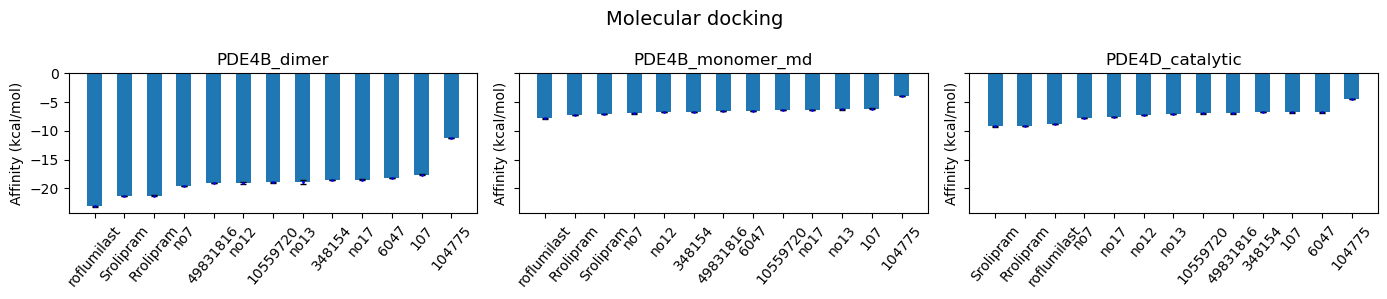

In [57]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
axes = axes.ravel()

#proteins = df_rep1["protein"].unique()
#proteins = df[df["protein"] != "PDE4B_monomer_md"]["protein"].unique()
#proteins = df["protein"].unique()
to_remove = ["PDE4B_monomer", "PDE4B_catalytic"]
proteins = df[~df["protein"].isin(to_remove)]["protein"].unique()

for ax, protein in zip(axes, proteins):
    sub = summary[summary["protein"] == protein].sort_values("mean_affinity")
    ax.bar(sub["ligand"], sub["mean_affinity"], width=0.5)
    ax.set_title(protein)
    ax.set_xticklabels(sub["ligand"], rotation=50)
    ax.set_ylabel("Affinity (kcal/mol)")
    ax.errorbar(
        sub["ligand"],
        sub["mean_affinity"],
        yerr=sub["std_affinity"],
        fmt="o",
        color="blue",
        ecolor="black",
        elinewidth=0.8,
        capsize=2,
        markersize=1
    )

fig.suptitle("Molecular docking", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

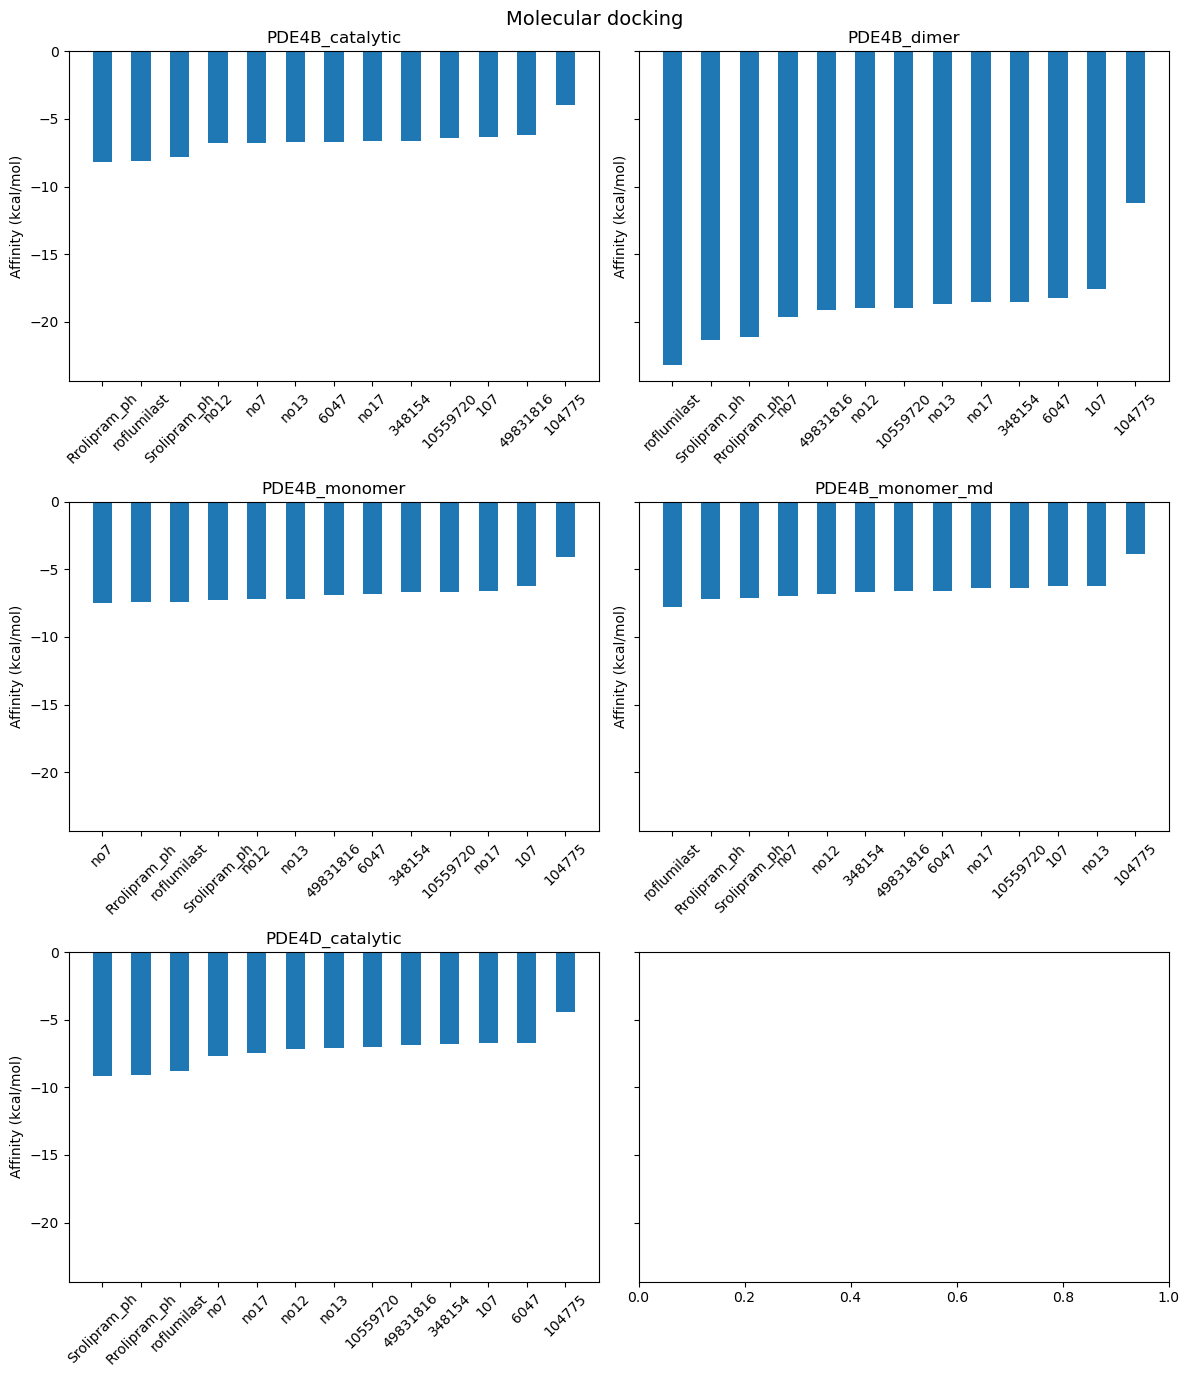

In [38]:
import matplotlib.pyplot as plt

df_rep1 = df[df["replicate"] == 1]

fig, axes = plt.subplots(3, 2, figsize=(10, 14), sharey=True)
axes = axes.ravel()

proteins = df_rep1["protein"].unique()
#proteins = df[df["protein"] != "PDE4B_monomer_md"]["protein"].unique()

for ax, protein in zip(axes, proteins):
    sub = df_rep1[df_rep1["protein"] == protein].sort_values("affinity")
    ax.bar(sub["ligand"], sub["affinity"], width=0.5)
    ax.set_title(protein)
    ax.set_xticklabels(sub["ligand"], rotation=45)
    ax.set_ylabel("Affinity (kcal/mol)")

fig.suptitle("Molecular docking", fontsize=14)
plt.tight_layout()
plt.show()